## 1) Environment Setup and Imports

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.naive_bayes import CategoricalNB

## 2) Load and Inspect Mushroom Dataset

In [47]:
df_raw = pd.read_csv("../../Mushroom Dataset/mushrooms 2.csv")

display(df_raw.head())
print('Shape:', df_raw.shape)

print('\nGeneral information:')
display(df_raw.info())

print('\nSummary (object columns):')
display(df_raw.describe(include='all'))

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Shape: (8124, 23)

General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-nul

None


Summary (object columns):


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148



Target distribution:


class
e    4208
p    3916
Name: count, dtype: int64

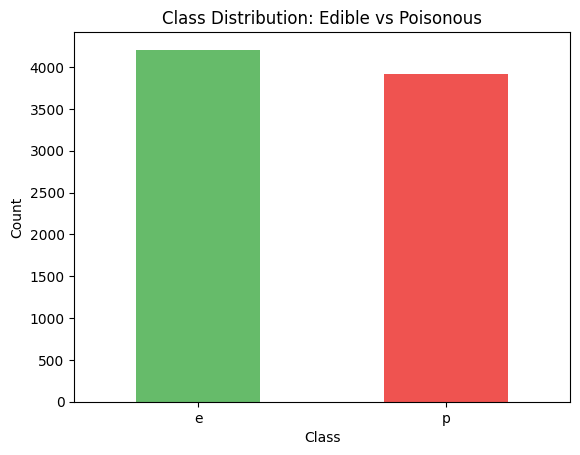

In [48]:
print('\nTarget distribution:')
display(df_raw['class'].value_counts())

plt.figure()
df_raw["class"].value_counts().plot( kind="bar", color=["#66bb6a", "#ef5350"], rot=0)
plt.title("Class Distribution: Edible vs Poisonous")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

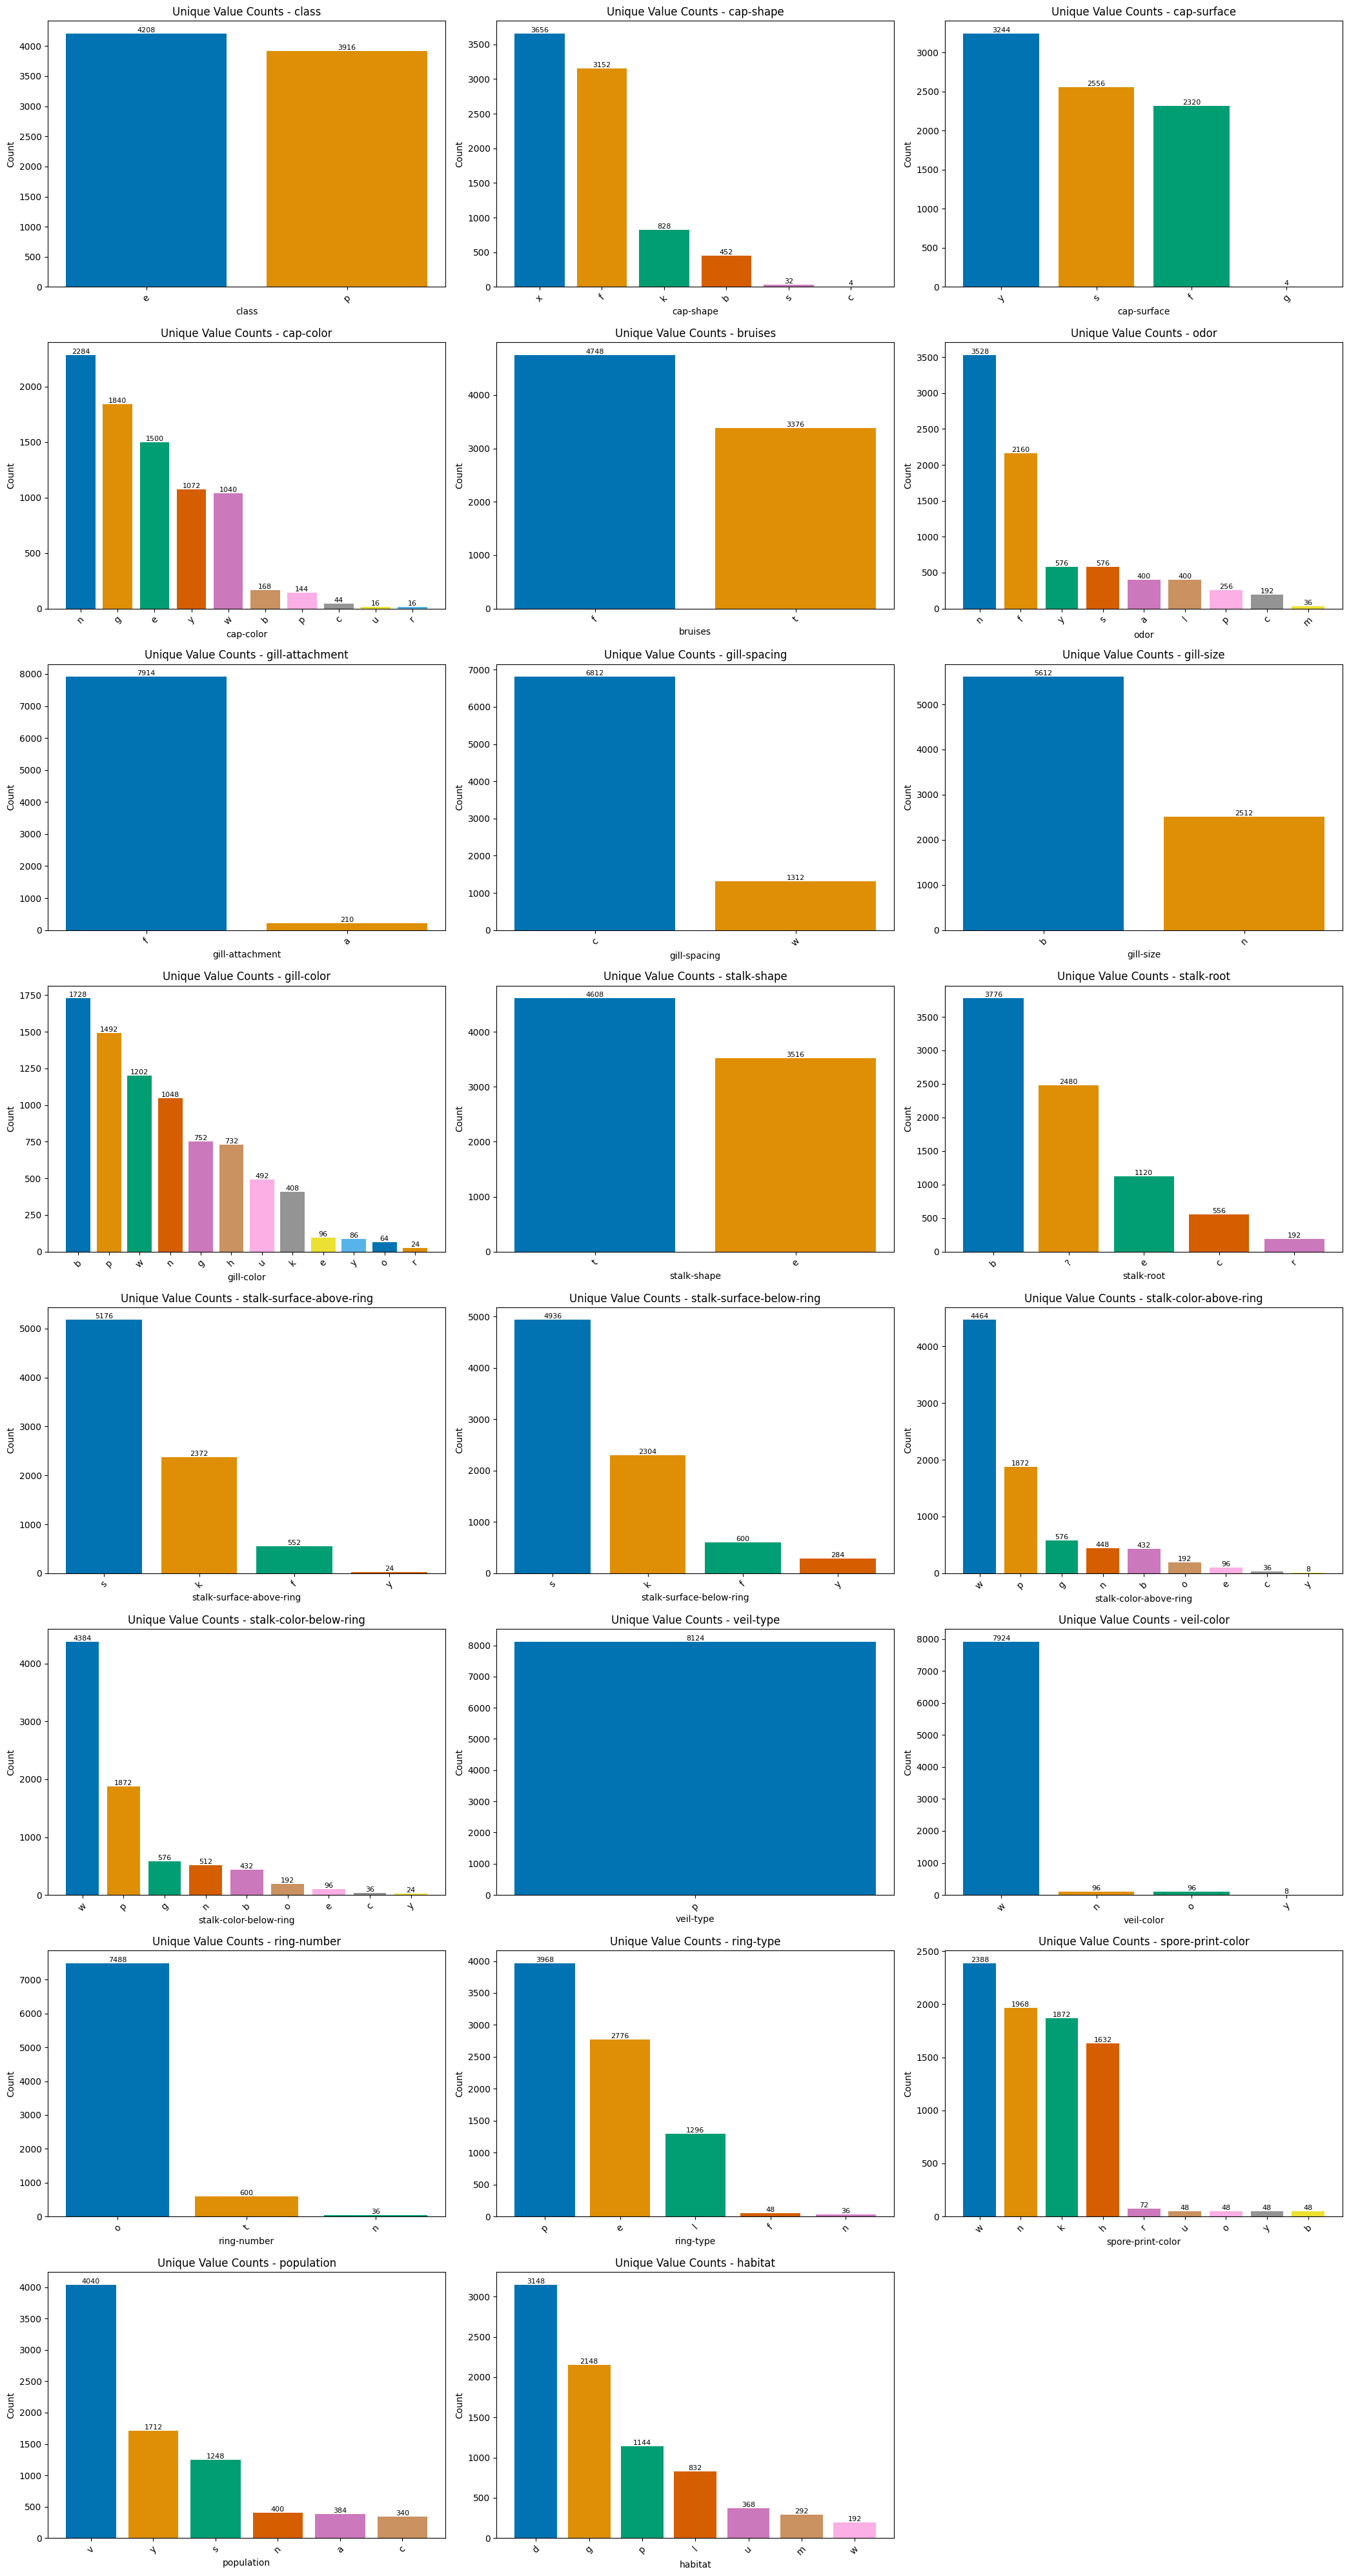

In [49]:
# Plot unique-value counts for each column.
counts_by_column = {}
for col in df_raw.columns:
    counts = df_raw[col].value_counts(dropna=False)
    counts_df = counts.rename_axis('value').reset_index(name='count')
    counts_df['value'] = counts_df['value'].astype(str)
    counts_by_column[col] = counts_df

num_cols = len(df_raw.columns)
grid_cols = 3
grid_rows = int(np.ceil(num_cols / grid_cols))

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(7 * grid_cols, 5 * grid_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(df_raw.columns):
    ax = axes[i]
    plot_df = counts_by_column[col].copy()

    colors = sns.color_palette('colorblind', n_colors=len(plot_df))
    bars = ax.bar(plot_df['value'], plot_df['count'], color=colors)

    ax.set_title(f'Unique Value Counts - {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    # Write count value on each bar.
    for bar, value in zip(bars, plot_df['count']):
        ax.text( bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(value)), 
                 ha='center', va='bottom', fontsize=8, rotation=0)

# Hide any unused subplot axes.
for j in range(num_cols, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 3) Preprocessing

In [50]:
df = df_raw.copy()

# Replace placeholder unknowns ?.
df = df.replace('?', np.nan)
print('\nMissing values per column before filling:')
display(df.isna().sum().sort_values(ascending=False))

# Drop duplicates.
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)
print(f'\nDropped {rows_before - rows_after} duplicate rows. Remaining rows: {rows_after}')


Missing values per column before filling:


stalk-root                  2480
stalk-surface-above-ring       0
population                     0
spore-print-color              0
ring-type                      0
ring-number                    0
veil-color                     0
veil-type                      0
stalk-color-below-ring         0
stalk-color-above-ring         0
stalk-surface-below-ring       0
class                          0
cap-shape                      0
stalk-shape                    0
gill-color                     0
gill-size                      0
gill-spacing                   0
gill-attachment                0
odor                           0
bruises                        0
cap-color                      0
cap-surface                    0
habitat                        0
dtype: int64


Dropped 0 duplicate rows. Remaining rows: 8124


In [51]:
# Categorical imputation for mushroom data.
df_filled = df.copy()

# Show stalk-root values before imputation (including missing)
print("\nstalk-root counts BEFORE fill:")
display(df_filled['stalk-root'].value_counts(dropna=False).rename('count').to_frame())

# Fill only stalk-root since it is the only column with missing values using mode
stalk_root_mode = df_filled['stalk-root'].mode(dropna=True)
stalk_root_fill = stalk_root_mode.iloc[0] if not stalk_root_mode.empty else 'missing'
df_filled['stalk-root'] = df_filled['stalk-root'].fillna(stalk_root_fill)

print(f'\nMissing values in stalk-root after fill: {df_filled["stalk-root"].isna().sum()}')

# Show stalk-root values after imputation 
print("\nstalk-root counts AFTER fill:")
display(df_filled['stalk-root'].value_counts(dropna=False).rename('count').to_frame())



stalk-root counts BEFORE fill:


,count
stalk-root,
b,3776
NaN,2480
e,1120
c,556
r,192



Missing values in stalk-root after fill: 0

stalk-root counts AFTER fill:


,count
stalk-root,
b,6256
e,1120
c,556
r,192


In [52]:
# Drop single-category features (no variance)
single_category_features = [col for col in df_filled.columns if df_filled[col].nunique() <= 1]
if single_category_features:
    df_filled = df_filled.drop(columns=single_category_features)
print(f"\nDropped features with single category: {single_category_features}")


Dropped features with single category: ['veil-type']


## 4) Outlier Detection

In [53]:
# Outlier Detection: Flag rows with rare categories (<1% frequency)
threshold = 0.01 * len(df_filled)
outlier_mask = pd.Series(False, index=df_filled.index)
outlier_details = []

for col in df_filled.columns:
    if col == 'class': continue 
    
    # Find categories appearing fewer than 'threshold' times
    counts = df_filled[col].value_counts()
    rare_cats = counts[counts < threshold].index.tolist()
    
    # 2. If any found, add to our "outlier list"
    if rare_cats:
        is_rare = df_filled[col].isin(rare_cats)
        outlier_mask |= is_rare 
        
        outlier_details.append({
            'Feature': col, 
            'Rare Values': rare_cats, 
            'Total Rows Affected': is_rare.sum()
        })

# Create the outlier tracking dataframe
outlier_df = df_filled.copy()
outlier_df['is_outlier'] = outlier_mask.astype(int)

print(f"Global Outliers Found: {outlier_mask.sum()} rows")
display(pd.DataFrame(outlier_details))

Global Outliers Found: 473 rows


,Feature,Rare Values,Total Rows Affected
0,cap-shape,"[s, c]",36
1,cap-surface,[g],4
2,cap-color,"[c, u, r]",76
3,odor,[m],36
4,gill-color,"[o, r]",88
5,stalk-surface-above-ring,[y],24
6,stalk-color-above-ring,"[c, y]",44
7,stalk-color-below-ring,"[c, y]",60
8,veil-color,[y],8
9,ring-number,[n],36


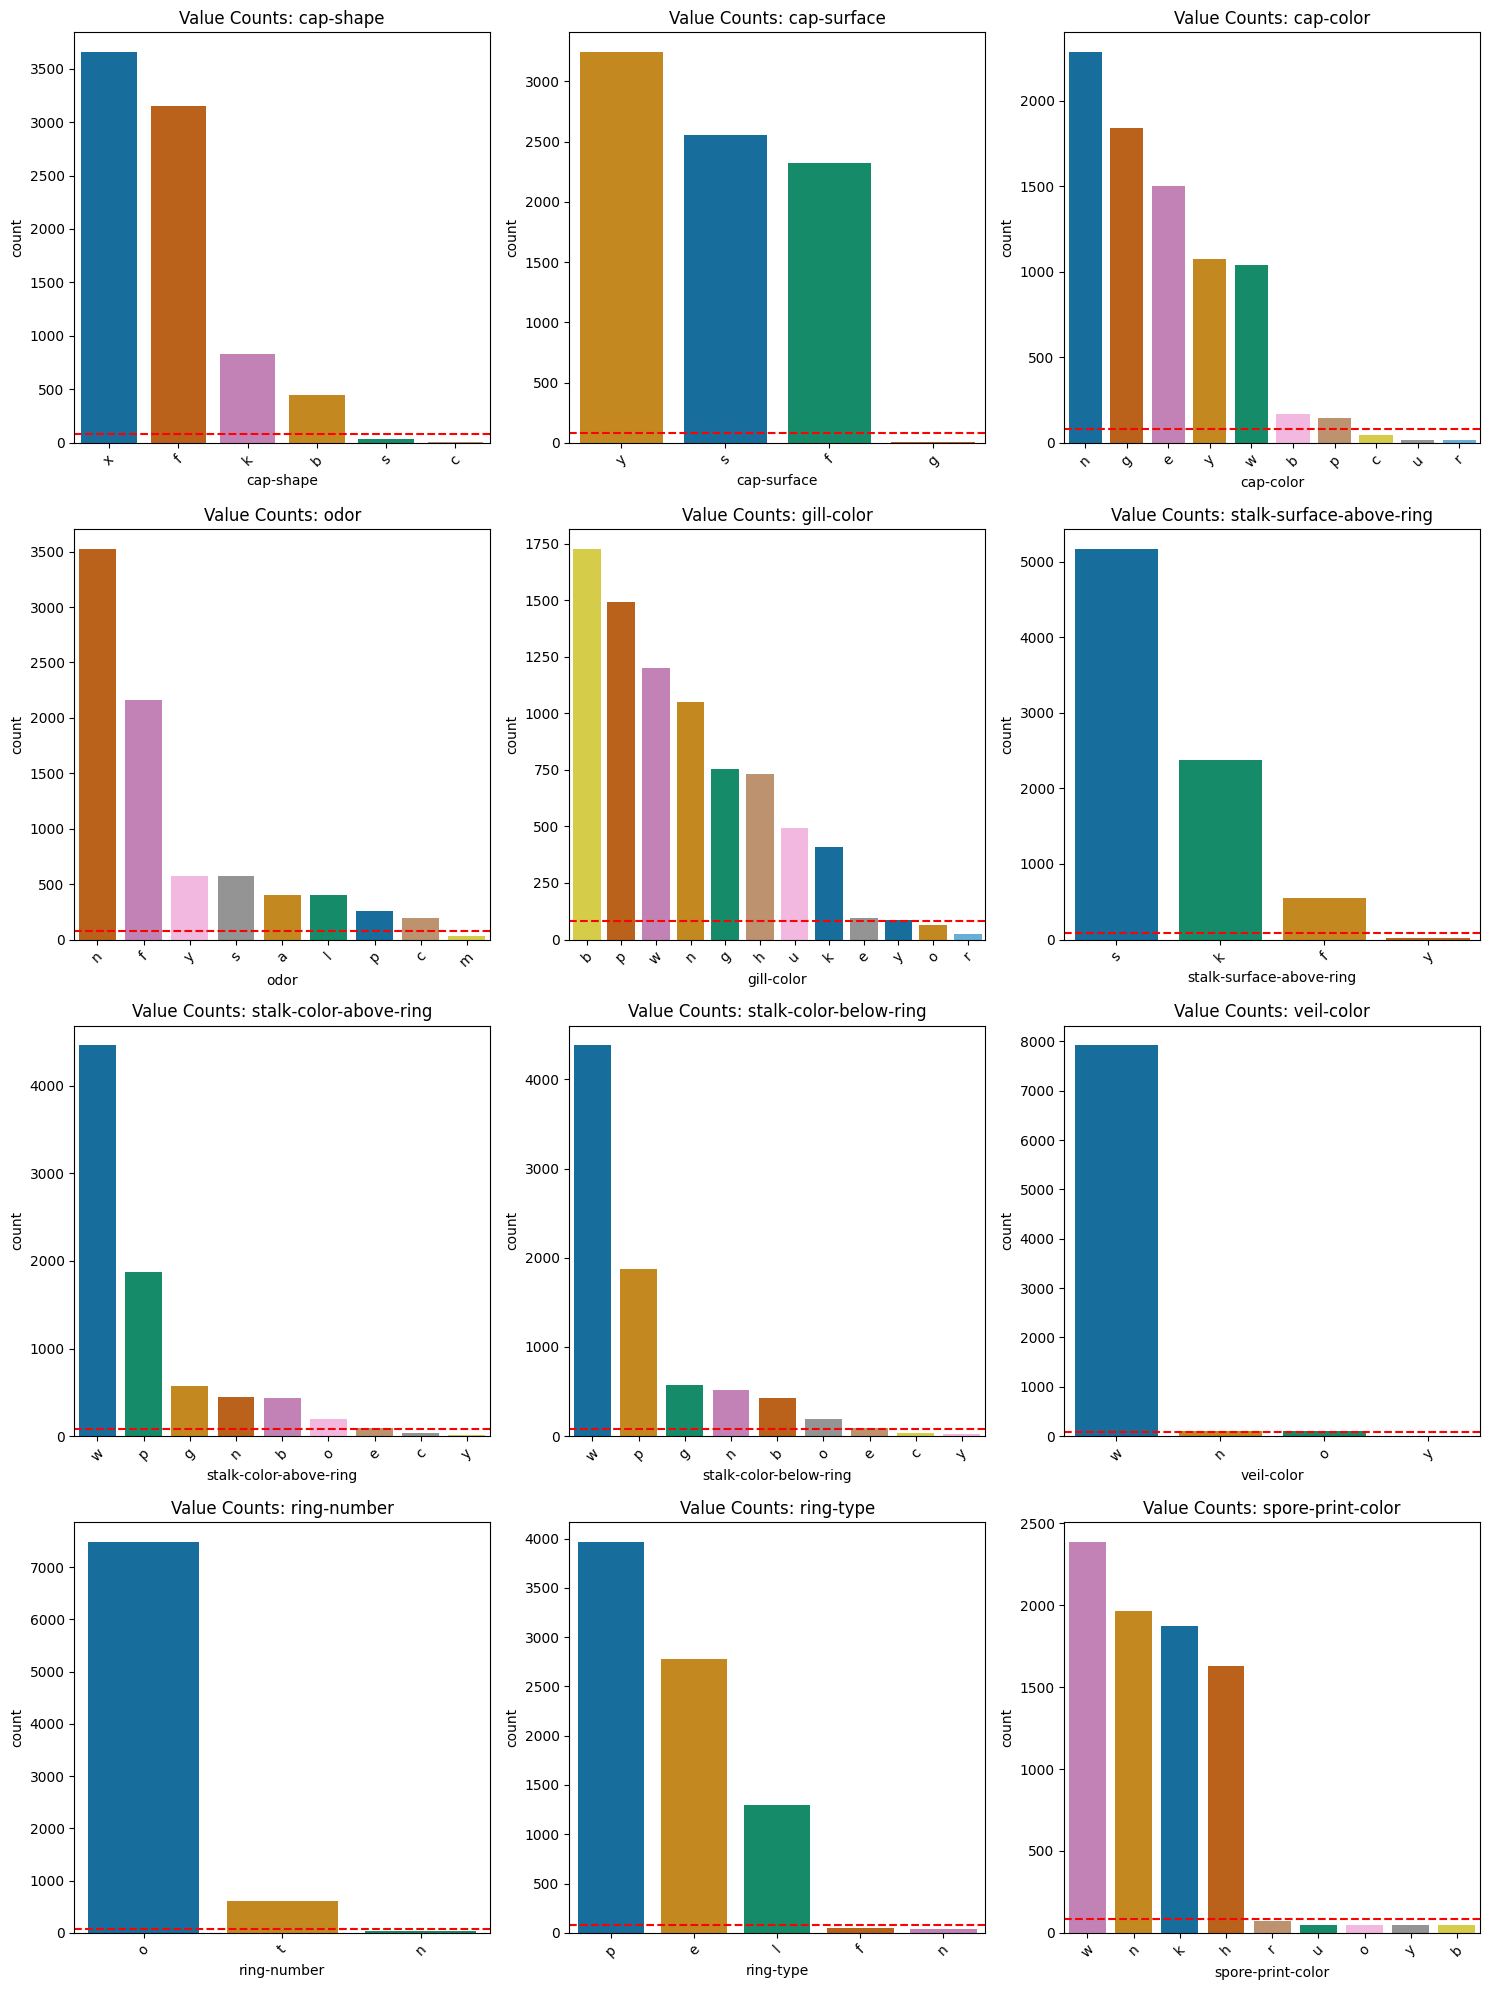

In [54]:
# Outlier Analysis Plots 
cols_with_outliers = [d['Feature'] for d in outlier_details]

n_cols = 3
n_rows = (len(cols_with_outliers) + 2) // 3 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_with_outliers):
    sns.countplot(data=df_filled, x=col, hue=col, ax=axes[i], order=df_filled[col].value_counts().index, palette='colorblind', legend=False)
    axes[i].set_title(f'Value Counts: {col}', fontsize=12)
    axes[i].axhline(y=threshold, color='r', linestyle='--', label='1% Threshold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

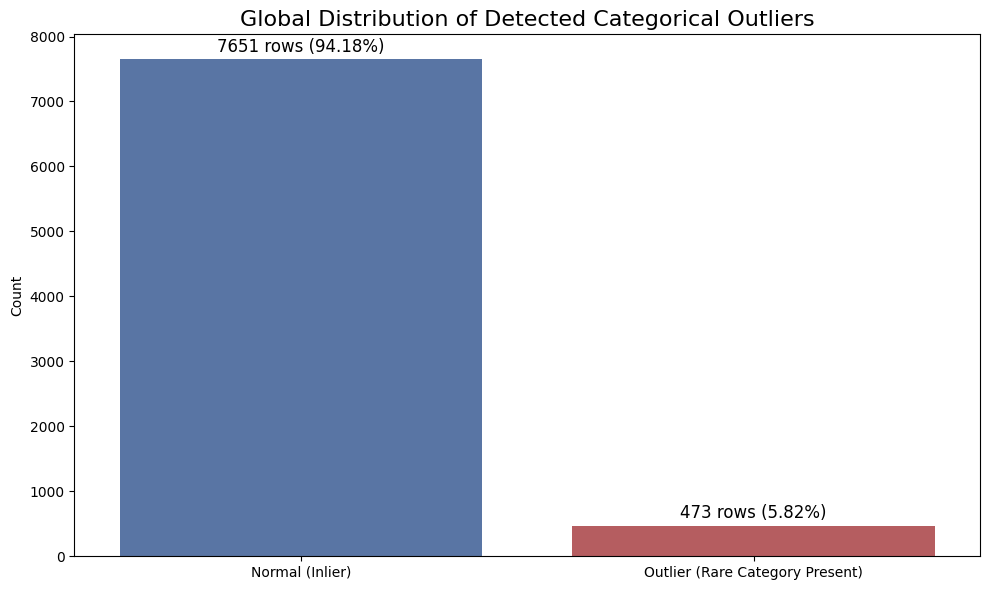

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat,is_outlier
15,e,s,f,g,f,n,f,c,n,k,...,s,w,w,w,o,p,n,y,u,1
36,e,s,f,g,f,n,f,c,n,k,...,s,w,w,w,o,p,k,v,u,1
60,e,s,f,g,f,n,f,c,n,k,...,s,w,w,w,o,p,n,v,u,1
76,e,x,s,w,t,l,f,w,n,n,...,s,w,w,w,o,p,u,v,d,1
89,e,s,f,n,f,n,f,c,n,n,...,s,w,w,w,o,p,n,v,u,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8115,e,x,s,n,f,n,a,c,b,y,...,s,o,o,o,o,p,o,v,l,1
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,o,o,p,b,c,l,1
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,n,o,p,b,v,l,1
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,o,o,p,b,c,l,1


In [55]:
# Global Dataset Outlier Distribution
plt.figure(figsize=(10, 6))
labels = ['Normal (Inlier)', 'Outlier (Rare Category Present)']
counts = outlier_df['is_outlier'].value_counts()

ax = sns.barplot(x=labels, y=counts, hue=labels, palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Global Distribution of Detected Categorical Outliers', fontsize=16)
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} rows ({p.get_height()/len(outlier_df)*100:.2f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), 
                textcoords = 'offset points', fontsize=12)

plt.tight_layout()
plt.show()

# Rows containing outliers 
display(outlier_df[outlier_df['is_outlier'] == 1])

## 5) Data Assessment and Correlation

In [56]:
# Choose Data Subset for Analysis
df_analysis = outlier_df[outlier_df['is_outlier'] == 0].drop(columns=['is_outlier'])
print(f"Dataset for assessment: {df_analysis.shape[0]} rows and {df_analysis.shape[1]} features.")

# Association Functions
def associations_matrix(df):
    cols = df.columns
    n = len(cols)
    cv_mtx = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
    tu_mtx = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i in range(n):
        for j in range(n):
            if i == j:
                cv_mtx.iloc[i, j] = 1.0
                tu_mtx.iloc[i, j] = 1.0
                continue
            
            c1, c2 = cols[i], cols[j]
            contingency = pd.crosstab(df[c1], df[c2])
            
            # Cramer's V (Symmetric)
            chi2 = chi2_contingency(contingency)[0]
            n_obs = contingency.sum().sum()
            r, k = contingency.shape
            cv_mtx.iloc[i, j] = np.sqrt(chi2 / (n_obs * min(k-1, r-1))) if n_obs > 0 and min(k-1, r-1) > 0 else 0
            
            # Theil's U (Asymmetric: how much X=c1 tells us about Y=c2)
            pxy = contingency / n_obs
            px = pxy.sum(axis=1)
            py = pxy.sum(axis=0)
            h_y = entropy(py, base=2)
            h_xy = entropy(pxy.values.flatten(), base=2)
            h_y_given_x = h_xy - entropy(px, base=2)
            tu_mtx.iloc[i, j] = (h_y - h_y_given_x) / h_y if h_y > 0 else 0

    return cv_mtx, tu_mtx

cramer_matrix, theils_matrix = associations_matrix(df_analysis)

Dataset for assessment: 7651 rows and 22 features.


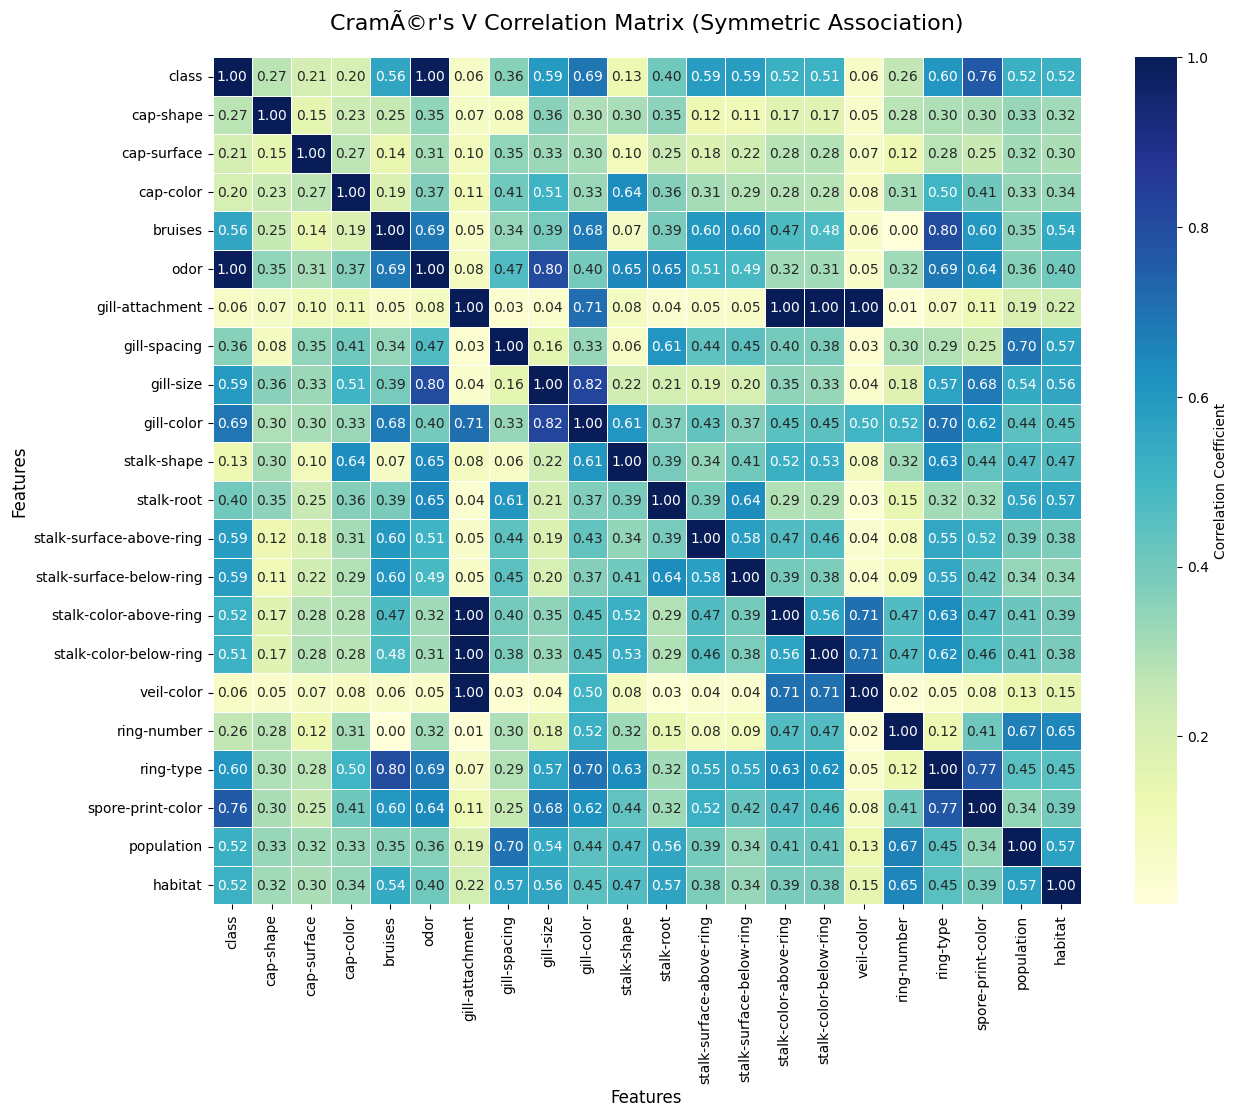


Top 10 correlated feature pairs based on CramÃ©r's V:
  - gill-attachment â†” veil-color: 1.000
  - gill-attachment â†” stalk-color-above-ring: 1.000
  - gill-attachment â†” stalk-color-below-ring: 1.000
  - class â†” odor: 0.995
  - gill-size â†” gill-color: 0.822
  - odor â†” gill-size: 0.805
  - bruises â†” ring-type: 0.803
  - ring-type â†” spore-print-color: 0.770
  - class â†” spore-print-color: 0.763
  - gill-attachment â†” gill-color: 0.711


In [57]:
# Association Visualization: CramÃ©r's V (Symmetric)
plt.figure(figsize=(14, 11))
sns.heatmap(cramer_matrix, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('CramÃ©r\'s V Correlation Matrix (Symmetric Association)', fontsize=16, pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# List Top Correlated Feature Pairs
pairs = []
for i in range(len(cramer_matrix.columns)):
    for j in range(i+1, len(cramer_matrix.columns)):
        pairs.append((cramer_matrix.columns[i], cramer_matrix.columns[j], cramer_matrix.iloc[i, j]))

# Print top 10 most correlated pairs
print("\nTop 10 correlated feature pairs based on CramÃ©r's V:")
for f1, f2, corr in sorted(pairs, key=lambda x: x[2], reverse=True)[:10]:
    print(f"  - {f1} â†” {f2}: {corr:.3f}")

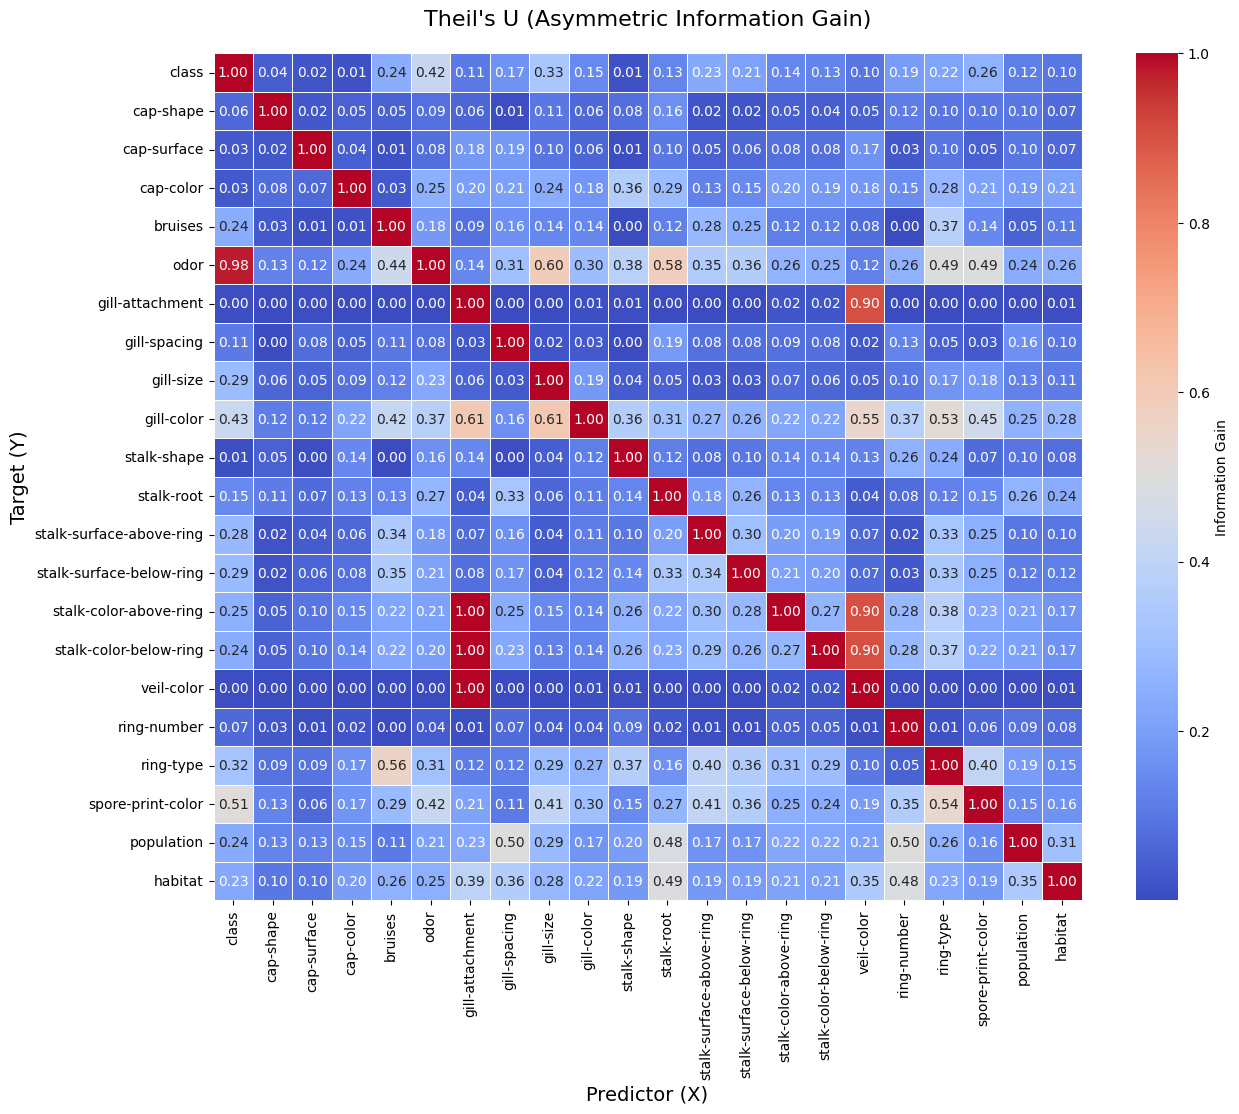


Predictive Insight (X provides more than 50% Information Gain about Y):
  - odor provides 97.81% information about class
  - ring-type provides 56.23% information about bruises
  - stalk-color-above-ring provides 100.00% information about gill-attachment
  - population provides 50.43% information about gill-spacing
  - gill-color provides 61.08% information about gill-size
  - odor provides 58.35% information about stalk-root
  - stalk-color-above-ring provides 90.33% information about veil-color
  - population provides 50.29% information about ring-number
  - spore-print-color provides 54.27% information about ring-type


In [58]:
# Association Visualization: Theil's U (Asymmetric)
plt.figure(figsize=(14, 11))
sns.heatmap(theils_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Information Gain'})
plt.title('Theil\'s U (Asymmetric Information Gain)', fontsize=16, pad=20)
plt.xlabel('Predictor (X)', fontsize=14)
plt.ylabel('Target (Y)', fontsize=14)
plt.show()

# Print specific insights for Theil's U (Information Gain > 50%)
print("\nPredictive Insight (X provides more than 50% Information Gain about Y):")
for col_y in theils_matrix.columns:
    strong_predictors = theils_matrix.loc[theils_matrix.index != col_y, col_y]
    max_feat = strong_predictors.idxmax()
    max_val = strong_predictors[max_feat]
    if max_val > 0.5:
        print(f"  - {max_feat} provides {max_val:.2%} information about {col_y}")

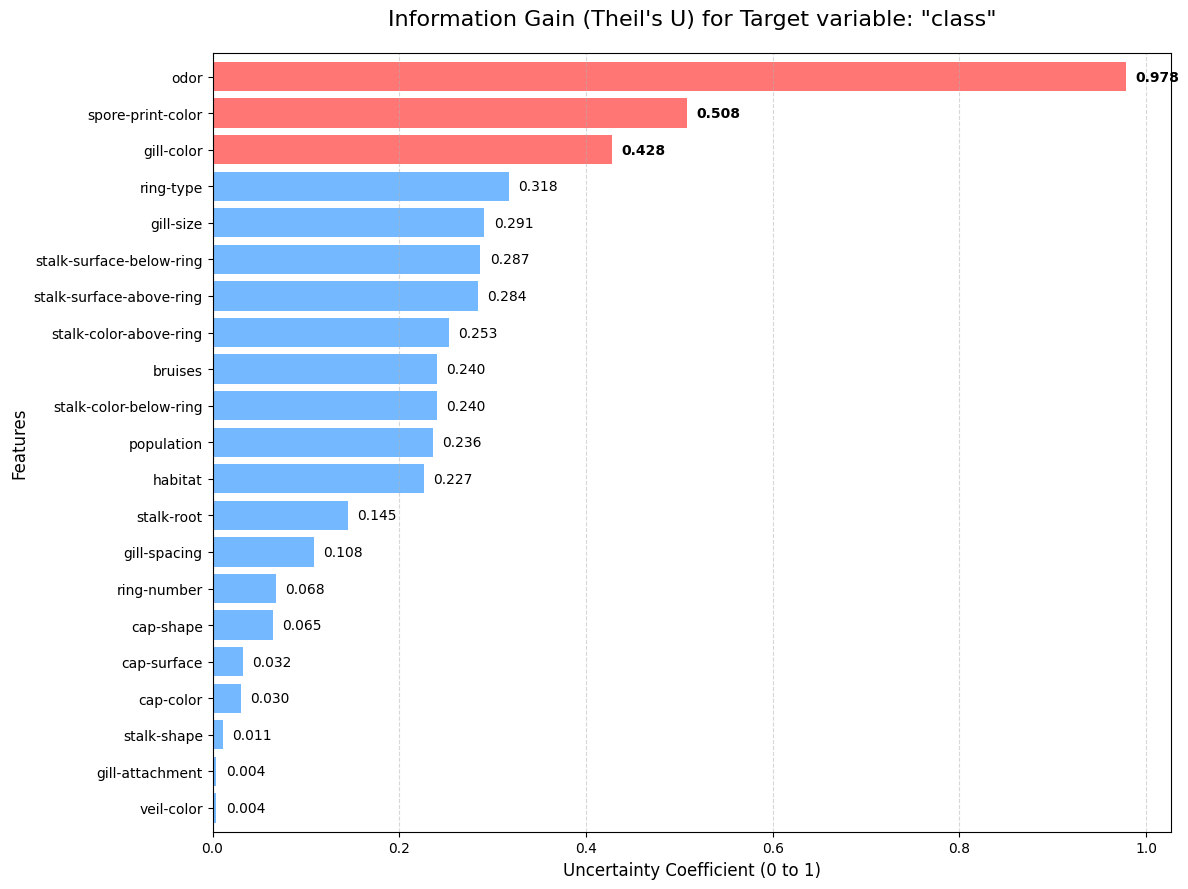

Top informers for mushroom toxicity ('class'):
  1. odor provides 97.81% information about poisoning status.
  2. spore-print-color provides 50.78% information about poisoning status.
  3. gill-color provides 42.76% information about poisoning status.
  4. ring-type provides 31.78% information about poisoning status.
  5. gill-size provides 29.13% information about poisoning status.


In [59]:
# Target Specific Importance for 'class' (poisoning status)
target_importances = theils_matrix['class'].drop('class').sort_values(ascending=False)

plt.figure(figsize=(12, 9))
# Use dual-color palette for emphasis: top 3 are coral, others are skyblue
colors = ['#ff7675' if i < 3 else '#74b9ff' for i in range(len(target_importances))]
ax = target_importances.plot(kind='barh', color=colors, width=0.8)

plt.title('Information Gain (Theil\'s U) for Target variable: "class"', fontsize=16, pad=20)
plt.xlabel('Uncertainty Coefficient (0 to 1)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()  # Put most informative on top
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value annotations to each bar
for i, v in enumerate(target_importances):
    plt.text(v + 0.01, i, f"{v:.3f}", color='black', va='center', fontweight='bold' if i < 3 else 'normal')

plt.tight_layout()
plt.show()

# Print Top Informers Summary
print(f"Top informers for mushroom toxicity ('class'):")
for i, (feat, val) in enumerate(target_importances[:5].items()):
    print(f"  {i+1}. {feat} provides {val:.2%} information about poisoning status.")

## 6) Categorical Encoding (Ordinal encoding)

In [60]:
df_model = outlier_df[outlier_df['is_outlier'] == 0].drop(columns=['is_outlier']).copy()

# Remove leakage-prone columns if they exist.
leakage_cols = [c for c in ['class_encoded'] if c in df_model.columns]
if leakage_cols:
    df_model = df_model.drop(columns=leakage_cols)

# Binary target encoding: edible (e)=0, poisonous (p)=1
y = df_model['class'].map({'e': 0, 'p': 1}).astype(int)
X = df_model.drop(columns=['class'])

# Train/test split before encoder fitting.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ordinal encoding for CategoricalNB input.
ordinal_encoder = OrdinalEncoder(dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat = pd.DataFrame(
    ordinal_encoder.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_cat = pd.DataFrame(
    ordinal_encoder.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print('Encoding Summary:')
print(f'  Original feature shape: {X.shape}')
print(f'  Train shape: {X_train_cat.shape}, Test shape: {X_test_cat.shape}')
print(f'  Target encoding: e -> 0, p -> 1')
print(f'  Train class balance (p=1): {y_train.mean():.3f}')
print(f'  Test class balance (p=1): {y_test.mean():.3f}')

display(X_train_cat.head(3))

Encoding Summary:
  Original feature shape: (7651, 21)
  Train shape: (6120, 21), Test shape: (1531, 21)
  Target encoding: e -> 0, p -> 1
  Train class balance (p=1): 0.494
  Test class balance (p=1): 0.494


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
4031,3,1,5,0,1,1,1,1,7,0,...,2,2,6,6,2,0,2,1,3,0
5011,1,0,2,0,2,1,0,0,2,0,...,1,1,5,5,2,0,1,0,4,1
555,1,2,6,1,0,1,0,0,6,0,...,2,3,6,6,2,0,2,1,5,4


## 7) CategoricalNB

In [61]:
# Train and evaluate CategoricalNB.
model = CategoricalNB()
model.fit(X_train_cat, y_train)
y_pred = model.predict(X_test_cat)
y_proba = model.predict_proba(X_test_cat)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc,
    'avg_precision': ap,
}
print('\nFinal metrics (CategoricalNB):')
display(pd.Series(metrics).round(4).to_frame('value'))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['edible', 'poisonous']))


Final metrics (CategoricalNB):


,value
accuracy,0.9660
precision,0.9930
recall,0.9378
f1,0.9646
roc_auc,0.9989
avg_precision,0.9990



Classification report:
              precision    recall  f1-score   support

      edible       0.94      0.99      0.97       775
   poisonous       0.99      0.94      0.96       756

    accuracy                           0.97      1531
   macro avg       0.97      0.97      0.97      1531
weighted avg       0.97      0.97      0.97      1531



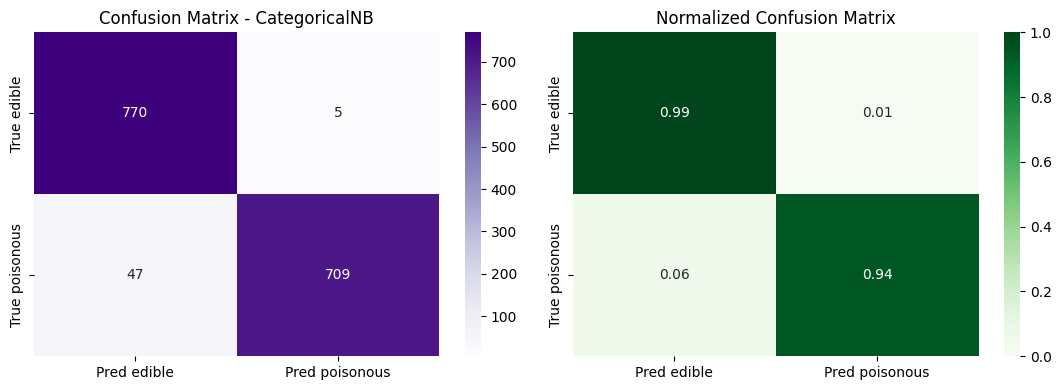

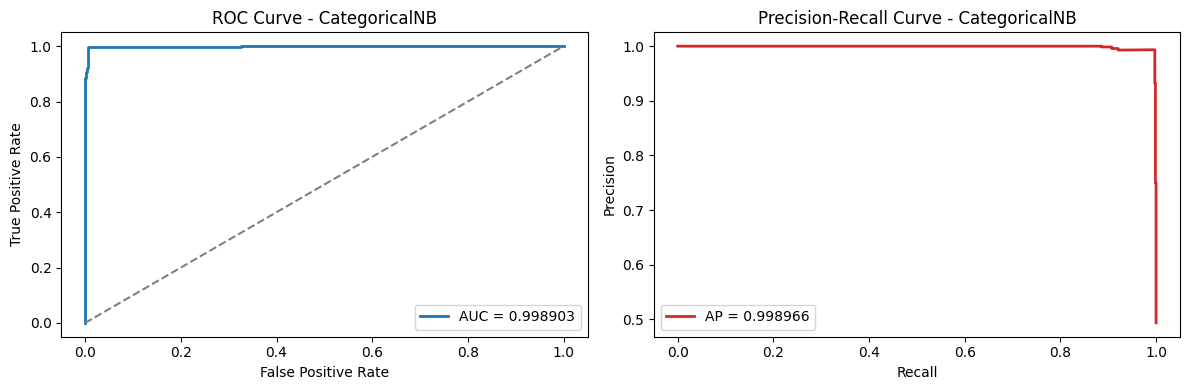

In [62]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Pred edible', 'Pred poisonous'], yticklabels=['True edible', 'True poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - CategoricalNB')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, xticklabels=['Pred edible', 'Pred poisonous'], yticklabels=['True edible', 'True poisonous'], ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'AUC = {roc_auc:.6f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - CategoricalNB')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].plot(rec, prec, color='#d62728', lw=2, label=f'AP = {ap:.6f}')
axes[1].set_title('Precision-Recall Curve - CategoricalNB')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()